# Singapore Bus Network Operations Management Analysis and LP Optimization  
# 新加坡公交网络运营管理分析与线性规划优化

This notebook uses the Singapore bus dataset to perform an **Operations Management (OM)** analysis and a **linear programming (LP)** optimization model.  
本 Notebook 基于新加坡公交数据集，完成一套**运营管理分析**与**线性规划优化模型**。

## Objectives / 研究目标
1. Understand the network structure and service characteristics.  
   理解公交网络结构与服务特征。
2. Apply OM concepts such as **process analysis, capacity, bottleneck, utilization, and waste identification**.  
   运用课程中的**流程分析、产能、瓶颈、利用率、浪费识别**等概念。
3. Build a runnable **LP model** to allocate additional weekday departures under a limited bus-hour budget.  
   构建一个可运行的**线性规划模型**，在有限车时预算下优化工作日加班次分配。

> Dataset source / 数据来源: Kaggle - Singapore Bus Data (Land Transport Authority)


In [24]:

# ================================
# 1) Import libraries / 导入库
# ================================
# English: Standard data analysis and optimization libraries
# 中文：标准数据分析与优化求解库

import os
import re
import math
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import linprog

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


In [25]:

# =============================================
# 2) Locate and extract dataset / 定位并解压数据
# =============================================
# English:
# The notebook first tries to find extracted CSV files in the current folder.
# If not found, it looks for the Kaggle zip file and extracts it automatically.
#
# 中文：
# Notebook 会先在当前目录寻找已解压的 CSV 文件；
# 如果没有找到，则会自动寻找 zip 压缩包并解压。

CANDIDATE_DIRS = [
    Path("."),
    Path("."),
]

ZIP_CANDIDATES = [
    Path("archive (2).zip"),
    Path("archive (2).zip"),
]

routes_file = None
services_file = None
stops_file = None

for folder in CANDIDATE_DIRS:
    r = folder / "bus_routes.csv"
    s = folder / "bus_services.csv"
    b = folder / "bus_stops.csv"
    if r.exists() and s.exists() and b.exists():
        routes_file, services_file, stops_file = r, s, b
        break

if routes_file is None:
    for zip_path in ZIP_CANDIDATES:
        if zip_path.exists():
            extract_dir = zip_path.parent / "bus_dataset_extracted"
            extract_dir.mkdir(exist_ok=True)
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(extract_dir)
            routes_file = extract_dir / "bus_routes.csv"
            services_file = extract_dir / "bus_services.csv"
            stops_file = extract_dir / "bus_stops.csv"
            break

if routes_file is None:
    raise FileNotFoundError("Could not find bus_routes.csv / 无法找到 bus_routes.csv")

print("Routes file / 路线文件:", routes_file)
print("Services file / 服务文件:", services_file)
print("Stops file / 站点文件:", stops_file)


Routes file / 路线文件: bus_dataset_extracted/bus_routes.csv
Services file / 服务文件: bus_dataset_extracted/bus_services.csv
Stops file / 站点文件: bus_dataset_extracted/bus_stops.csv


In [26]:

# ======================================
# 3) Load data / 读取数据
# ======================================
# English: Read the three core files.
# 中文：读取 3 个核心数据表。

routes = pd.read_csv(routes_file)
services = pd.read_csv(services_file)
stops = pd.read_csv(stops_file)

print("routes shape:", routes.shape)
print("services shape:", services.shape)
print("stops shape:", stops.shape)

display(routes.head())
display(services.head())
display(stops.head())


routes shape: (26317, 13)
services shape: (729, 12)
stops shape: (5021, 6)


,Unnamed: 0,ServiceNo,Operator,Direction,StopSequence,BusStopCode,Distance,WD_FirstBus,WD_LastBus,SAT_FirstBus,SAT_LastBus,SUN_FirstBus,SUN_LastBus
0,0,10,SBST,1,1,75009,0.000,0500,2300,0500,2300,0500,2300
1,1,10,SBST,1,2,76059,0.600,0502,2302,0502,2302,0502,2302
2,2,10,SBST,1,3,76069,1.100,0504,2304,0504,2304,0503,2304
3,3,10,SBST,1,4,96289,2.300,0508,2308,0508,2309,0507,2308
4,4,10,SBST,1,5,96109,2.700,0509,2310,0509,2311,0508,2309


,Unnamed: 0,ServiceNo,Operator,Direction,Category,OriginCode,DestinationCode,AM_Peak_Freq,AM_Offpeak_Freq,PM_Peak_Freq,PM_Offpeak_Freq,LoopDesc
0,0,118,GAS,1,TRUNK,"65,009.000","97,009.000",06-08,08-15,10-12,11-15,NaN
1,1,118,GAS,2,TRUNK,"97,009.000","65,009.000",10,10-12,05-11,10-15,NaN
2,2,118A,GAS,1,TRUNK,"65,199.000","96,119.000",14-16,-,-,-,NaN
3,3,118B,GAS,1,TRUNK,"96,111.000","65,191.000",-,-,30,-,NaN
4,4,119,GAS,1,TRUNK,"65,009.000","65,009.000",16-08,18-12,17-12,15-17,Hougang St 21


,Unnamed: 0,BusStopCode,RoadName,Description,Latitude,Longitude
0,0,481,Woodlands Rd,BT PANJANG TEMP BUS PK,1.384,103.758
1,1,1012,Victoria St,Hotel Grand Pacific,1.297,103.853
2,2,1013,Victoria St,St. Joseph's Ch,1.298,103.853
3,3,1019,Victoria St,Bras Basah Cplx,1.297,103.853
4,4,1029,Nth Bridge Rd,Cosmic Insurance Bldg,1.297,103.854


In [27]:

# ======================================
# 4) Basic cleaning / 基础清洗
# ======================================
# English:
# - Remove unnamed index columns
# - Standardize key code columns to string
# - Clean obvious data issues
#
# 中文：
# - 删除自动生成的索引列
# - 统一关键编码字段为字符串
# - 清理明显的数据问题

def drop_unnamed(df):
    return df.loc[:, ~df.columns.str.contains("^Unnamed")].copy()

routes = drop_unnamed(routes)
services = drop_unnamed(services)
stops = drop_unnamed(stops)

routes["BusStopCode"] = routes["BusStopCode"].astype(str)
stops["BusStopCode"] = stops["BusStopCode"].astype(str)

services["ServiceNo"] = services["ServiceNo"].astype(str)
routes["ServiceNo"] = routes["ServiceNo"].astype(str)

# Standardize some code columns / 标准化部分编码列
for col in ["OriginCode", "DestinationCode"]:
    if col in services.columns:
        services[col] = services[col].astype("Int64").astype(str)

print(routes.info())
print(services.info())
print(stops.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26317 entries, 0 to 26316
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ServiceNo     26317 non-null  object 
 1   Operator      26317 non-null  object 
 2   Direction     26317 non-null  int64  
 3   StopSequence  26317 non-null  int64  
 4   BusStopCode   26317 non-null  object 
 5   Distance      26312 non-null  float64
 6   WD_FirstBus   26317 non-null  object 
 7   WD_LastBus    26317 non-null  object 
 8   SAT_FirstBus  26317 non-null  object 
 9   SAT_LastBus   26317 non-null  object 
 10  SUN_FirstBus  26317 non-null  object 
 11  SUN_LastBus   26317 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.4+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729 entries, 0 to 728
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ServiceNo        729 n

In [28]:

# ======================================================
# 5) Helper functions / 辅助函数
# ======================================================
# English:
# We need to parse timetable values and frequency ranges such as '10-15'.
#
# 中文：
# 需要解析时刻字段，以及类似 '10-15' 的发车间隔范围。

def parse_hhmm(value):
    #\"\"\"Convert HHMM string into minutes from midnight / 将 HHMM 字符串转换为从零点开始的分钟数\"\"\"
    if pd.isna(value):
        return np.nan
    s = str(value).strip()
    if s in {"-", "", "nan", "None"}:
        return np.nan
    s = s.zfill(4)
    if not re.fullmatch(r"\d{4}", s):
        return np.nan
    hh = int(s[:2])
    mm = int(s[2:])
    return hh * 60 + mm

def service_span(first_bus, last_bus):
    #\"\"\"Compute daily operating span in minutes / 计算每日运营时长（分钟）\"\"\"
    if pd.isna(first_bus) or pd.isna(last_bus):
        return np.nan
    span = last_bus - first_bus
    # If the service crosses midnight / 如果跨过午夜
    if span < 0:
        span += 24 * 60
    return span

def parse_freq_range(value):
    #\"\"\"Convert frequency text like '10-15' into average headway in minutes / 将频率范围解析为平均发车间隔（分钟）\"\"\"
    if pd.isna(value):
        return np.nan
    s = str(value).strip()
    if s in {"-", "", "nan", "None"}:
        return np.nan
    nums = re.findall(r"\d+", s)
    if len(nums) == 0:
        return np.nan
    nums = [float(x) for x in nums]
    return float(np.mean(nums))

def zscore(series):
    std = series.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.mean()) / std


In [29]:

# ======================================================
# 6) Derive route-level summary / 构建线路层面的汇总表
# ======================================================
# English:
# Aggregate stop-level route records into route-direction level metrics.
#
# 中文：
# 将逐站点的路线数据汇总成“线路-方向”层面的运营指标。

# Parse weekday timetable / 解析工作日首末班时间
routes["WD_FirstBus_min"] = routes["WD_FirstBus"].apply(parse_hhmm)
routes["WD_LastBus_min"] = routes["WD_LastBus"].apply(parse_hhmm)
routes["WD_ServiceSpan_min"] = routes.apply(
    lambda x: service_span(x["WD_FirstBus_min"], x["WD_LastBus_min"]), axis=1
)

# Route-direction summary / 按线路+方向汇总
route_summary = (
    routes.groupby(["ServiceNo", "Direction", "Operator"], as_index=False)
    .agg(
        n_stops=("StopSequence", "max"),
        route_distance_km=("Distance", "max"),
        wd_first_min=("WD_FirstBus_min", "min"),
        wd_last_min=("WD_LastBus_min", "max"),
        wd_service_span_min=("WD_ServiceSpan_min", "max"),
        unique_stops=("BusStopCode", "nunique"),
    )
)

# Parse weekday frequencies from bus_services / 解析工作日发车间隔
services["AM_Peak_headway_min"] = services["AM_Peak_Freq"].apply(parse_freq_range)
services["AM_Offpeak_headway_min"] = services["AM_Offpeak_Freq"].apply(parse_freq_range)
services["PM_Peak_headway_min"] = services["PM_Peak_Freq"].apply(parse_freq_range)
services["PM_Offpeak_headway_min"] = services["PM_Offpeak_Freq"].apply(parse_freq_range)

services["avg_wd_headway_min"] = services[
    ["AM_Peak_headway_min", "AM_Offpeak_headway_min", "PM_Peak_headway_min", "PM_Offpeak_headway_min"]
].mean(axis=1, skipna=True)

service_summary = services[
    ["ServiceNo", "Direction", "Category", "OriginCode", "DestinationCode", "avg_wd_headway_min"]
].copy()

# Merge route structure + service information / 合并路线结构与班次信息
route_summary = route_summary.merge(
    service_summary,
    on=["ServiceNo", "Direction"],
    how="left"
)

# Estimate trips and cycle time
# 估算单程运行时间与每日理论班次数
ASSUMED_SPEED_KMPH = 18   # English: average commercial speed / 中文：假设平均商业速度
DWELL_MIN_PER_STOP = 0.35 # English: average dwell time / 中文：假设站点停靠时间

route_summary["one_way_trip_time_min"] = (
    route_summary["route_distance_km"] / ASSUMED_SPEED_KMPH * 60
    + route_summary["n_stops"] * DWELL_MIN_PER_STOP
)

route_summary["baseline_daily_trips"] = (
    route_summary["wd_service_span_min"] / route_summary["avg_wd_headway_min"]
)

# Replace impossible values / 替换异常值
route_summary["baseline_daily_trips"] = route_summary["baseline_daily_trips"].replace([np.inf, -np.inf], np.nan)
route_summary["baseline_daily_trips"] = route_summary["baseline_daily_trips"].fillna(route_summary["baseline_daily_trips"].median())

display(route_summary.head())
print(route_summary.shape)


,ServiceNo,Direction,Operator,n_stops,route_distance_km,wd_first_min,wd_last_min,wd_service_span_min,unique_stops,Category,OriginCode,DestinationCode,avg_wd_headway_min,one_way_trip_time_min,baseline_daily_trips
0,10,1,SBST,74,31.700,300.000,"1,440.000","1,081.000",74,TRUNK,75009,16009,11.750,131.567,92.000
1,10,2,SBST,74,31.900,360.000,"1,440.000","1,107.000",74,TRUNK,16009,75009,12.625,132.233,87.683
2,100,1,SBST,55,23.600,330.000,"1,440.000","1,096.000",55,TRUNK,66009,11009,12.375,97.917,88.566
3,100,2,SBST,54,23.300,360.000,"1,440.000","1,094.000",54,TRUNK,11009,66009,10.375,96.567,105.446
4,100A,1,SBST,13,4.700,399.000,"1,195.000",776.000,13,TRUNK,66009,81089,22.167,20.217,35.008


(727, 15)


In [30]:

# ======================================================
# 7) Create OM indicators / 构建运营管理指标
# ======================================================
# English:
# Build route-level indicators aligned with OM concepts:
# - capacity proxy
# - bottleneck score
# - route complexity
#
# 中文：
# 构建与运营管理概念对应的线路指标：
# - 产能代理变量
# - 瓶颈评分
# - 线路复杂度

# A proxy for offered service output / 供给能力代理
route_summary["offered_stop_visits_per_day"] = (
    route_summary["baseline_daily_trips"] * route_summary["n_stops"]
)

# Complexity score / 复杂度评分
route_summary["complexity_score"] = (
    zscore(route_summary["route_distance_km"]) * 0.40
    + zscore(route_summary["n_stops"]) * 0.35
    + zscore(route_summary["one_way_trip_time_min"]) * 0.25
)

# Bottleneck score:
# routes with long trip time and long headway are more likely to be operationally stressed
# 瓶颈评分：运行时间长且发车间隔也长的线路，更容易形成运营压力
route_summary["bottleneck_score"] = (
    zscore(route_summary["one_way_trip_time_min"]) * 0.50
    + zscore(route_summary["avg_wd_headway_min"].fillna(route_summary["avg_wd_headway_min"].median())) * 0.30
    + zscore(route_summary["n_stops"]) * 0.20
)

# Simple utilization proxy:
# more offered stop visits divided by trip time => stronger throughput intensity
# 利用率代理：每日停站服务量 / 单程时间
route_summary["throughput_intensity"] = (
    route_summary["offered_stop_visits_per_day"] / route_summary["one_way_trip_time_min"]
)

route_summary = route_summary.sort_values("complexity_score", ascending=False).reset_index(drop=True)

display(route_summary[[
    "ServiceNo", "Direction", "Operator", "n_stops", "route_distance_km",
    "wd_service_span_min", "avg_wd_headway_min", "one_way_trip_time_min",
    "baseline_daily_trips", "complexity_score", "bottleneck_score"
]].head(15))


,ServiceNo,Direction,Operator,n_stops,route_distance_km,wd_service_span_min,avg_wd_headway_min,one_way_trip_time_min,baseline_daily_trips,complexity_score,bottleneck_score
0,858,1,SMRT,83,73.500,"1,176.000",7.250,274.050,162.207,4.024,2.568
1,518,1,GAS,91,59.900,"1,016.000",17.500,231.517,58.057,3.386,2.534
2,502,1,SBST,89,59.600,"1,055.000",17.250,229.817,61.159,3.332,2.485
3,24,1,SBST,103,51.700,"1,122.000",10.625,208.383,105.600,3.135,2.099
4,966,1,SMRT,63,63.600,"1,065.000",11.500,234.050,92.609,3.080,2.065
5,53,1,SBST,87,53.000,"1,169.000",9.125,207.117,128.110,2.913,1.874
6,70M,1,SBST,105,42.000,286.000,14.375,176.750,19.896,2.612,1.885
7,160,1,SBST,84,48.700,"1,135.000",16.375,191.733,69.313,2.609,1.946
8,NR7,1,SMRT,106,41.100,NaN,29.000,174.100,85.545,2.578,2.437
9,36,1,GAS,67,52.700,"1,122.000",9.125,199.117,122.959,2.524,1.590


In [31]:

# ======================================================
# 8) OM descriptive analysis / 运营管理描述性分析
# ======================================================
# English: Identify long routes, high-stop routes, and potential bottlenecks.
# 中文：识别长线路、多站点线路和潜在瓶颈线路。

top_distance = route_summary.nlargest(10, "route_distance_km")[
    ["ServiceNo", "Direction", "Operator", "route_distance_km", "n_stops", "one_way_trip_time_min"]
]

top_stops = route_summary.nlargest(10, "n_stops")[
    ["ServiceNo", "Direction", "Operator", "n_stops", "route_distance_km", "one_way_trip_time_min"]
]

top_bottleneck = route_summary.nlargest(10, "bottleneck_score")[
    ["ServiceNo", "Direction", "Operator", "avg_wd_headway_min", "one_way_trip_time_min", "bottleneck_score"]
]

print("Top 10 longest routes / 最长线路 Top 10")
display(top_distance)

print("Top 10 highest-stop routes / 站点最多线路 Top 10")
display(top_stops)

print("Top 10 potential bottlenecks / 潜在瓶颈线路 Top 10")
display(top_bottleneck)


Top 10 longest routes / 最长线路 Top 10


,ServiceNo,Direction,Operator,route_distance_km,n_stops,one_way_trip_time_min
0,858,1,SMRT,73.500,83,274.050
4,966,1,SMRT,63.600,63,234.050
1,518,1,GAS,59.900,91,231.517
2,502,1,SBST,59.600,89,229.817
5,53,1,SBST,53.000,87,207.117
9,36,1,GAS,52.700,67,199.117
3,24,1,SBST,51.700,103,208.383
7,160,1,SBST,48.700,84,191.733
31,27,1,SBST,44.500,55,167.583
61,35,1,SBST,43.500,36,157.600


Top 10 highest-stop routes / 站点最多线路 Top 10


,ServiceNo,Direction,Operator,n_stops,route_distance_km,one_way_trip_time_min
8,NR7,1,SMRT,106,41.100,174.100
6,70M,1,SBST,105,42.000,176.750
3,24,1,SBST,103,51.700,208.383
12,63,1,SBST,103,38.900,165.717
13,61,1,SMRT,97,39.600,165.950
14,162M,1,SBST,97,39.000,163.950
15,51,1,SBST,97,37.800,159.950
10,89,1,SBST,95,43.400,177.917
17,961C,2,SMRT,95,37.400,157.917
19,51,2,SBST,95,36.000,153.250


Top 10 potential bottlenecks / 潜在瓶颈线路 Top 10


,ServiceNo,Direction,Operator,avg_wd_headway_min,one_way_trip_time_min,bottleneck_score
45,36B,1,GAS,54.333,154.267,2.722
16,4N,1,SBST,40.000,168.733,2.597
0,858,1,SMRT,7.250,274.050,2.568
1,518,1,GAS,17.500,231.517,2.534
2,502,1,SBST,17.250,229.817,2.485
8,NR7,1,SMRT,29.000,174.100,2.437
398,67W,1,SMRT,77.000,66.317,2.395
25,2N,1,SBST,40.000,156.300,2.391
32,3N,1,SBST,40.000,153.867,2.305
33,5N,1,SBST,40.000,153.867,2.305


/Users/huanghaojie/Desktop/PE6012/Student Learning Predict/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/huanghaojie/Desktop/PE6012/Student Learning Predict/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 36335 (\N{CJK UNIFIED IDEOGRAPH-8DEF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/huanghaojie/Desktop/PE6012/Student Learning Predict/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/huanghaojie/Desktop/PE6012/Student Learning Predict/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 31163 (\N{CJK UNIFIED IDEOGRAPH-79BB}) missing from font(s) DejaVu Sans.
  fig.

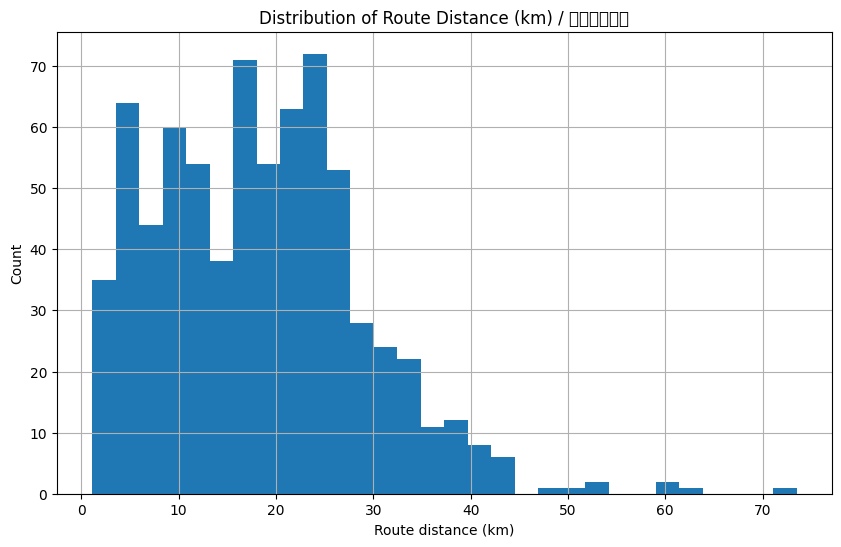

/Users/huanghaojie/Desktop/PE6012/Student Learning Predict/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 31449 (\N{CJK UNIFIED IDEOGRAPH-7AD9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/huanghaojie/Desktop/PE6012/Student Learning Predict/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/huanghaojie/Desktop/PE6012/Student Learning Predict/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/huanghaojie/Desktop/PE6012/Student Learning Predict/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.

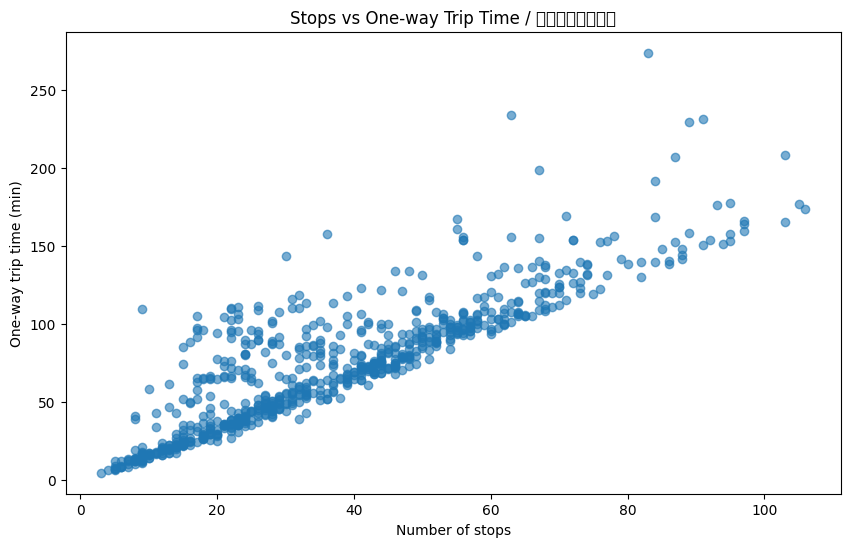

/Users/huanghaojie/Desktop/PE6012/Student Learning Predict/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 28508 (\N{CJK UNIFIED IDEOGRAPH-6F5C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/huanghaojie/Desktop/PE6012/Student Learning Predict/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/huanghaojie/Desktop/PE6012/Student Learning Predict/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 29942 (\N{CJK UNIFIED IDEOGRAPH-74F6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/huanghaojie/Desktop/PE6012/Student Learning Predict/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 39048 (\N{CJK UNIFIED IDEOGRAPH-9888}) missing from font(s) DejaVu Sans.
  fig.

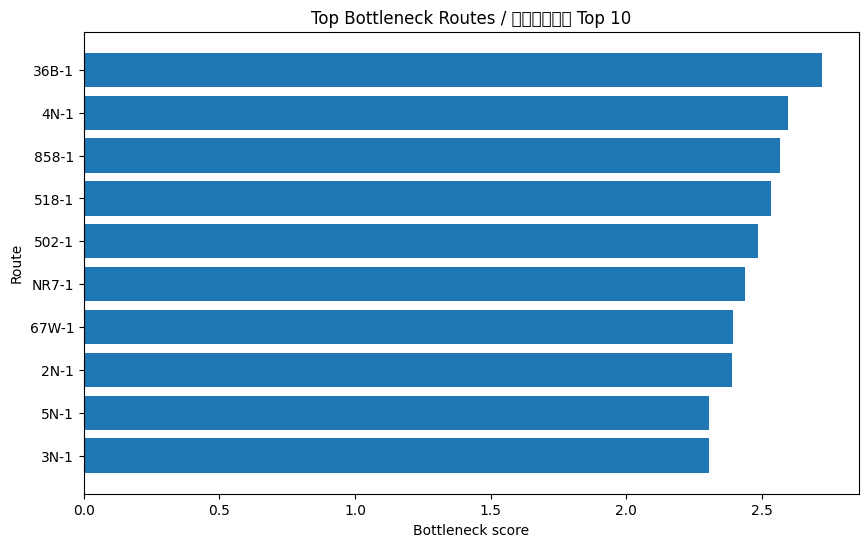

In [32]:

# ======================================================
# 9) Visualizations / 可视化
# ======================================================
# English: A few core charts for report and presentation.
# 中文：生成适合报告与展示的核心图表。

# Chart 1: distance distribution / 路线距离分布
plt.figure()
route_summary["route_distance_km"].hist(bins=30)
plt.title("Distribution of Route Distance (km) / 线路距离分布")
plt.xlabel("Route distance (km)")
plt.ylabel("Count")
plt.show()

# Chart 2: scatter of stops vs trip time / 站点数与单程时间散点图
plt.figure()
plt.scatter(route_summary["n_stops"], route_summary["one_way_trip_time_min"], alpha=0.6)
plt.title("Stops vs One-way Trip Time / 站点数与单程时间")
plt.xlabel("Number of stops")
plt.ylabel("One-way trip time (min)")
plt.show()

# Chart 3: top bottleneck routes / 主要瓶颈线路
plot_df = route_summary.nlargest(10, "bottleneck_score").sort_values("bottleneck_score")
labels = plot_df["ServiceNo"] + "-" + plot_df["Direction"].astype(str)

plt.figure()
plt.barh(labels, plot_df["bottleneck_score"])
plt.title("Top Bottleneck Routes / 潜在瓶颈线路 Top 10")
plt.xlabel("Bottleneck score")
plt.ylabel("Route")
plt.show()


## Singapore map-based route visualization / 结合新加坡地图的公交动线可视化

This section adds geographic visualizations using bus stop latitude/longitude.  
这一部分基于公交站点经纬度，在新加坡地图上展示公交线路动线。

Included views / 包含视图：
1. **All bus stops map** / 全部公交站点分布图  
2. **Single route movement line** / 单条线路动线图  
3. **Top bottleneck routes on one Singapore map** / 重点瓶颈线路叠加图  


In [33]:
# ======================================================
# 9A) Build geo-merged route data / 构建带地理坐标的线路数据
# ======================================================
# English:
# Merge route stop sequence with stop latitude/longitude so that we can draw route paths.
# 中文：
# 将线路逐站顺序数据与站点经纬度合并，用于绘制线路动线。

# Optional dependency check / 可选依赖检查
try:
    import folium
    from folium.plugins import MarkerCluster
except ImportError:
    raise ImportError("Please install folium first: pip install folium")

# Standardize stop code before merge / 合并前统一站点编码格式
stops_geo = stops.copy()
stops_geo['BusStopCode'] = stops_geo['BusStopCode'].astype(str).str.replace(r'\.0$', '', regex=True)

route_geo = routes.merge(
    stops_geo[['BusStopCode', 'Latitude', 'Longitude', 'RoadName', 'Description']],
    on='BusStopCode',
    how='left'
)

# Remove rows without coordinates / 删除缺失坐标的记录
route_geo = route_geo.dropna(subset=['Latitude', 'Longitude']).copy()

print('route_geo shape:', route_geo.shape)
print(route_geo[['ServiceNo', 'Direction', 'StopSequence', 'BusStopCode', 'Latitude', 'Longitude']].head())


route_geo shape: (23708, 19)
  ServiceNo  Direction  StopSequence BusStopCode  Latitude  Longitude
0        10          1             1       75009     1.354    103.943
1        10          1             2       76059     1.353    103.942
2        10          1             3       76069     1.349    103.942
3        10          1             4       96289     1.340    103.948
4        10          1             5       96109     1.337    103.951


In [34]:
# ======================================================
# 9B) All bus stops map / 全部公交站点地图
# ======================================================
# English:
# Plot bus stops as clustered markers on a Singapore-centered map.
# 中文：
# 在以新加坡为中心的地图上，用聚类点显示公交站点分布。

sg_center = [stops_geo['Latitude'].mean(), stops_geo['Longitude'].mean()]
all_stops_map = folium.Map(location=sg_center, zoom_start=11, tiles='CartoDB positron')
marker_cluster = MarkerCluster(name='Bus Stops').add_to(all_stops_map)

# Sample markers to keep rendering light in notebook / 为了控制 notebook 渲染负担，仅抽样部分站点标记
sample_stops = stops_geo.dropna(subset=['Latitude', 'Longitude']).sample(
    n=min(1200, len(stops_geo.dropna(subset=['Latitude', 'Longitude']))),
    random_state=42
)

for _, row in sample_stops.iterrows():
    popup_text = f"{row['BusStopCode']} - {row.get('Description', '')}"
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        popup=popup_text,
        fill=True,
        fill_opacity=0.7
    ).add_to(marker_cluster)

all_stops_map


In [35]:
# ======================================================
# 9C) Single route movement line / 单条线路动线图
# ======================================================
# English:
# Choose one route and direction, then draw the ordered stop-to-stop polyline.
# By default, we show the highest bottleneck-score route if route_summary exists.
# 中文：
# 选择一条线路和方向，按站点顺序绘制动线。
# 默认展示 route_summary 中 bottleneck_score 最高的一条线路（如果存在）。

def draw_route_map(service_no, direction=1, zoom_start=12):
    subset = route_geo[(route_geo['ServiceNo'].astype(str) == str(service_no)) & 
                       (route_geo['Direction'] == direction)].sort_values('StopSequence')
    if subset.empty:
        raise ValueError(f'No route data found for ServiceNo={service_no}, Direction={direction}')

    center = [subset['Latitude'].mean(), subset['Longitude'].mean()]
    m = folium.Map(location=center, zoom_start=zoom_start, tiles='CartoDB positron')

    # Draw ordered path / 绘制有序路径
    points = subset[['Latitude', 'Longitude']].values.tolist()
    folium.PolyLine(points, weight=5, opacity=0.8, popup=f'Route {service_no} Dir {direction}').add_to(m)

    # Add start/end markers / 标记起点和终点
    first_row = subset.iloc[0]
    last_row = subset.iloc[-1]
    folium.Marker(
        [first_row['Latitude'], first_row['Longitude']],
        popup=f"Start: {first_row['Description']} ({first_row['BusStopCode']})",
        tooltip='Start / 起点',
        icon=folium.Icon(icon='play', prefix='fa')
    ).add_to(m)
    folium.Marker(
        [last_row['Latitude'], last_row['Longitude']],
        popup=f"End: {last_row['Description']} ({last_row['BusStopCode']})",
        tooltip='End / 终点',
        icon=folium.Icon(icon='stop', prefix='fa', color='red')
    ).add_to(m)

    # Show a few intermediate stops / 显示部分中间站点，避免过于拥挤
    step = max(1, len(subset) // 12)
    for _, row in subset.iloc[::step].iterrows():
        folium.CircleMarker(
            [row['Latitude'], row['Longitude']],
            radius=4,
            popup=f"{row['StopSequence']}: {row['Description']} ({row['BusStopCode']})",
            fill=True,
            fill_opacity=0.8
        ).add_to(m)
    return m

if 'route_summary' in globals() and 'bottleneck_score' in route_summary.columns and len(route_summary) > 0:
    example_row = route_summary.sort_values('bottleneck_score', ascending=False).iloc[0]
    example_service = example_row['ServiceNo']
    example_direction = int(example_row['Direction'])
else:
    example_service = route_geo['ServiceNo'].astype(str).iloc[0]
    example_direction = int(route_geo['Direction'].iloc[0])

print(f"Example route shown / 当前展示线路: ServiceNo={example_service}, Direction={example_direction}")
single_route_map = draw_route_map(example_service, example_direction)
single_route_map


Example route shown / 当前展示线路: ServiceNo=36B, Direction=1


In [17]:
# ======================================================
# 9D) Top bottleneck routes on Singapore map / 瓶颈线路叠加地图
# ======================================================
# English:
# Overlay several top bottleneck routes on one map for comparison.
# 中文：
# 将若干条重点瓶颈线路叠加在同一张新加坡地图上，便于比较。

from matplotlib import cm, colors

if 'route_summary' in globals() and 'bottleneck_score' in route_summary.columns:
    top_routes_map = folium.Map(location=sg_center, zoom_start=11, tiles='CartoDB positron')
    top_n = 5
    top_routes = route_summary.sort_values('bottleneck_score', ascending=False).head(top_n).copy()

    cmap = cm.get_cmap('tab10', top_n)
    for idx, (_, r) in enumerate(top_routes.iterrows()):
        s_no = str(r['ServiceNo'])
        d_no = int(r['Direction'])
        subset = route_geo[(route_geo['ServiceNo'].astype(str) == s_no) & 
                           (route_geo['Direction'] == d_no)].sort_values('StopSequence')
        if len(subset) < 2:
            continue
        hex_color = colors.to_hex(cmap(idx))
        pts = subset[['Latitude', 'Longitude']].values.tolist()
        folium.PolyLine(
            pts,
            weight=4,
            color=hex_color,
            opacity=0.85,
            tooltip=f"Service {s_no} Dir {d_no} | Bottleneck Score: {r['bottleneck_score']:.2f}"
        ).add_to(top_routes_map)

    top_routes[['ServiceNo', 'Direction', 'route_distance_km', 'n_stops', 'bottleneck_score']]
    top_routes_map
else:
    print('route_summary or bottleneck_score not found. Please run earlier OM analysis cells first.')

/var/folders/mq/42h_20dd6550fywpscjwzb_h0000gn/T/ipykernel_14195/1711879689.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', top_n)


In [15]:
# ======================================================
# 9E) Export interactive maps / 导出交互式地图
# ======================================================
# English:
# Save HTML map files so they can be opened separately or embedded in presentation material.
# 中文：
# 导出 HTML 地图文件，便于单独打开或用于展示材料。

map_output_dir = Path('bus_outputs')
map_output_dir.mkdir(exist_ok=True)

all_stops_html = map_output_dir / 'singapore_bus_stops_map.html'
single_route_html = map_output_dir / f'singapore_route_{example_service}_dir_{example_direction}.html'

all_stops_map.save(str(all_stops_html))
single_route_map.save(str(single_route_html))
print('Saved:', all_stops_html)
print('Saved:', single_route_html)

if 'top_routes_map' in globals():
    top_routes_html = map_output_dir / 'singapore_top_bottleneck_routes_map.html'
    top_routes_map.save(str(top_routes_html))
    print('Saved:', top_routes_html)


Saved: bus_outputs/singapore_bus_stops_map.html
Saved: bus_outputs/singapore_route_36B_dir_1.html
Saved: bus_outputs/singapore_top_bottleneck_routes_map.html



## Operations Management Interpretation / 运营管理解读

### 1. Process analysis / 流程分析
A bus route can be treated as a service process:  
一条公交线路可以被视为一个服务流程：  
**dispatch → travel → stop servicing → arrival → turnaround**  
**发车 → 行驶 → 站点服务 → 到达 → 周转**

### 2. Capacity / 产能
For a route, capacity is constrained by:
- service span / 运营时长
- headway / 发车间隔
- trip time / 单程运行时间

### 3. Bottleneck / 瓶颈
Potential bottlenecks are routes with:
- long one-way trip time / 单程时间长
- many stops / 站点多
- relatively infrequent weekday service / 班次不够密

### 4. Lean waste / 精益浪费
Possible wastes include:
- waiting / 等待
- unnecessary route overlap / 冗余重叠
- uneven workload (Mura) / 负荷不均
- overburden (Muri) on long routes / 长线路资源过载


In [18]:

# ======================================================
# 10) Build LP dataset / 构建线性规划输入数据
# ======================================================
# English:
# We now formulate a capacity-allocation LP.
# Decision variable = additional weekday departures allocated to each route.
#
# 中文：
# 下面构建“班次增量分配”的线性规划模型。
# 决策变量 = 每条线路新增的工作日班次数。

# Focus on routes with valid service data / 仅保留有效服务数据线路
lp_df = route_summary.copy()
lp_df = lp_df[
    lp_df["one_way_trip_time_min"].notna()
    & lp_df["baseline_daily_trips"].notna()
    & (lp_df["baseline_daily_trips"] > 0)
].copy()

# Select a manageable subset for optimization:
# choose top 25 routes by bottleneck score
# 选择瓶颈得分最高的前25条线路进入优化
lp_df = lp_df.nlargest(25, "bottleneck_score").copy().reset_index(drop=True)

# Priority score for extra departures:
# routes with higher bottleneck score and complexity get more benefit from extra departures
# 新增班次的优先级：瓶颈越高、复杂度越高，越值得增加班次
lp_df["priority_score"] = (
    0.6 * zscore(lp_df["bottleneck_score"])
    + 0.4 * zscore(lp_df["complexity_score"])
)

# Shift to positive coefficients for LP maximization
# 将优先级平移到正数，便于线性规划求解
lp_df["priority_score"] = lp_df["priority_score"] - lp_df["priority_score"].min() + 1

# Upper bound: allow at most 25% more trips than baseline
# 上界：每条线路新增班次最多为当前基准班次的 25%
lp_df["max_additional_trips"] = np.ceil(lp_df["baseline_daily_trips"] * 0.25)

# Resource consumption of each extra trip:
# one extra departure consumes one one-way trip time
# 每增加 1 个班次，需要消耗 1 次单程运行时间资源
lp_df["trip_resource_hours"] = lp_df["one_way_trip_time_min"] / 60.0

# Total additional bus-hour budget (scenario parameter)
# 总新增车时预算（场景参数）
EXTRA_BUS_HOURS_BUDGET = 120

display(lp_df[[
    "ServiceNo", "Direction", "Operator", "baseline_daily_trips",
    "one_way_trip_time_min", "trip_resource_hours",
    "priority_score", "max_additional_trips"
]])


,ServiceNo,Direction,Operator,baseline_daily_trips,one_way_trip_time_min,trip_resource_hours,priority_score,max_additional_trips
0,36B,1,GAS,10.656,154.267,2.571,3.093,3.000
1,4N,1,SBST,85.545,168.733,2.812,3.112,22.000
2,858,1,SMRT,162.207,274.050,4.567,3.797,41.000
3,518,1,GAS,58.057,231.517,3.859,3.478,15.000
4,502,1,SBST,61.159,229.817,3.830,3.367,16.000
5,NR7,1,SMRT,85.545,174.100,2.902,2.973,22.000
6,67W,1,SMRT,85.545,66.317,1.105,1.797,22.000
7,2N,1,SBST,85.545,156.300,2.605,2.623,22.000
8,3N,1,SBST,85.545,153.867,2.564,2.421,22.000
9,5N,1,SBST,85.545,153.867,2.564,2.421,22.000


In [19]:

# ======================================================
# 11) Solve LP model / 求解线性规划模型
# ======================================================
# English:
# Objective:
#   maximize Σ priority_i * additional_trips_i
# Subject to:
#   Σ resource_hours_i * additional_trips_i <= budget
#   0 <= additional_trips_i <= upper bound
#
# Because scipy.linprog performs minimization, we minimize the negative objective.
#
# 中文：
# 目标：
#   最大化 Σ 优先级_i * 新增班次_i
# 约束：
#   Σ 资源消耗_i * 新增班次_i <= 预算
#   0 <= 新增班次_i <= 上界
#
# 由于 scipy.linprog 默认求最小值，因此这里最小化负的目标函数。

c = -lp_df["priority_score"].to_numpy()  # maximize -> minimize negative / 最大化转最小化
A_ub = np.array([lp_df["trip_resource_hours"].to_numpy()])
b_ub = np.array([EXTRA_BUS_HOURS_BUDGET])

bounds = list(zip(np.zeros(len(lp_df)), lp_df["max_additional_trips"].to_numpy()))

result = linprog(
    c=c,
    A_ub=A_ub,
    b_ub=b_ub,
    bounds=bounds,
    method="highs"
)

print("Optimization status / 求解状态:", result.message)
print("Optimal objective value / 最优目标值:", -result.fun if result.success else None)


Optimization status / 求解状态: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimal objective value / 最优目标值: 145.25464192777625


In [20]:

# ======================================================
# 12) Optimization results / 优化结果
# ======================================================
# English:
# Show how extra departures are allocated under the budget.
#
# 中文：
# 展示在预算约束下，新增班次如何分配到各条线路。

if result.success:
    lp_df["optimal_additional_trips"] = result.x
    lp_df["optimal_additional_trips_round"] = np.floor(lp_df["optimal_additional_trips"] + 1e-6)
    lp_df["resource_used_hours"] = lp_df["optimal_additional_trips"] * lp_df["trip_resource_hours"]
    lp_df["new_total_trips"] = lp_df["baseline_daily_trips"] + lp_df["optimal_additional_trips"]

    cols = [
        "ServiceNo", "Direction", "Operator",
        "baseline_daily_trips", "optimal_additional_trips",
        "new_total_trips", "trip_resource_hours",
        "resource_used_hours", "priority_score"
    ]
    display(lp_df[cols].sort_values("optimal_additional_trips", ascending=False).head(15))

    print("Total resource used (hours) / 总资源使用（小时）:", lp_df["resource_used_hours"].sum())
else:
    print("LP did not solve successfully / 线性规划未成功求解")


,ServiceNo,Direction,Operator,baseline_daily_trips,optimal_additional_trips,new_total_trips,trip_resource_hours,resource_used_hours,priority_score
6,67W,1,SMRT,85.545,22.000,107.545,1.105,24.316,1.797
1,4N,1,SBST,85.545,22.000,107.545,2.812,61.869,3.112
5,NR7,1,SMRT,85.545,7.827,93.372,2.902,22.712,2.973
11,67A,1,SMRT,13.857,4.000,17.857,0.848,3.390,1.176
0,36B,1,GAS,10.656,3.000,13.656,2.571,7.713,3.093
15,NR6,1,SMRT,85.545,0.000,85.545,2.546,0.000,1.942
23,6N,1,SBST,85.545,0.000,85.545,2.278,0.000,1.000
22,162M,1,SBST,23.119,0.000,23.119,2.732,0.000,1.396
21,NR2,1,SMRT,85.545,0.000,85.545,2.394,0.000,1.111
20,89,1,SBST,92.750,0.000,92.750,2.965,0.000,1.638


Total resource used (hours) / 总资源使用（小时）: 120.00000000000001


In [21]:

# ======================================================
# 13) Managerial interpretation / 管理含义解释
# ======================================================
# English:
# A simple operational impact estimate:
# If a route receives more departures, average waiting time is expected to fall.
# We use a rough proxy: average waiting time ≈ headway / 2
#
# 中文：
# 一个简化的管理效果估算：
# 如果某条线路增加了班次，则平均等待时间通常会下降。
# 这里用一个近似：平均等待时间 ≈ 发车间隔 / 2

impact_df = lp_df.copy()

# Current and new headway proxy / 当前与优化后的发车间隔代理
impact_df["current_headway_proxy"] = impact_df["wd_service_span_min"] / impact_df["baseline_daily_trips"]
impact_df["new_headway_proxy"] = impact_df["wd_service_span_min"] / impact_df["new_total_trips"]

impact_df["estimated_wait_reduction_min"] = (
    impact_df["current_headway_proxy"] - impact_df["new_headway_proxy"]
) / 2

display(
    impact_df[[
        "ServiceNo", "Direction", "baseline_daily_trips", "new_total_trips",
        "current_headway_proxy", "new_headway_proxy", "estimated_wait_reduction_min"
    ]]
    .sort_values("estimated_wait_reduction_min", ascending=False)
    .head(15)
)


,ServiceNo,Direction,baseline_daily_trips,new_total_trips,current_headway_proxy,new_headway_proxy,estimated_wait_reduction_min
11,67A,1,13.857,17.857,77.000,59.752,8.624
0,36B,1,10.656,13.656,54.333,42.398,5.968
2,858,1,162.207,162.207,7.250,7.250,0.000
3,518,1,58.057,58.057,17.500,17.500,0.000
4,502,1,61.159,61.159,17.250,17.250,0.000
13,24,1,105.600,105.600,10.625,10.625,0.000
14,966,1,92.609,92.609,11.500,11.500,0.000
17,160,1,69.313,69.313,16.375,16.375,0.000
18,70M,1,19.896,19.896,14.375,14.375,0.000
19,53,1,128.110,128.110,9.125,9.125,0.000



## Suggested write-up for report / 报告可直接使用的写法

### OM diagnosis / 运营问题诊断
1. Some routes have long one-way trip times and many stops, which increases operational complexity.  
   一些线路单程时间长、站点多，导致运营复杂度更高。  
2. Routes with long trip times and relatively loose weekday frequencies are more likely to become bottlenecks.  
   单程运行时间长且工作日发车间隔偏大的线路，更容易形成系统瓶颈。  
3. From a lean perspective, long routes and uneven headways may create waiting waste and workload imbalance.  
   从精益视角看，长线路与不均匀发车间隔会带来等待浪费和负荷不均。

### LP recommendation / 线性规划优化建议
Under a limited additional bus-hour budget, allocate extra weekday departures to the most operationally stressed routes.  
在有限新增车时预算下，应优先向运营压力更高的线路分配新增工作日班次。

### Why this model fits the course / 为什么该模型符合课程要求
- Capacity planning / 产能规划  
- Bottleneck improvement / 瓶颈改善  
- Data-driven operational decision / 数据驱动运营决策  
- Optimization model / 优化模型


In [22]:

# ======================================================
# 14) Export outputs / 导出结果
# ======================================================
# English: Save the route summary and LP results for report writing.
# 中文：导出线路汇总表与 LP 结果，便于写报告。

output_dir = Path("./bus_om_outputs")
output_dir.mkdir(exist_ok=True)

route_summary.to_csv(output_dir / "route_summary.csv", index=False)
lp_df.to_csv(output_dir / "lp_optimization_results.csv", index=False)

print("Files saved to / 文件已保存到:", output_dir.resolve())


Files saved to / 文件已保存到: /Users/huanghaojie/Downloads/bus_om_outputs



## Next possible extensions / 后续可扩展方向
1. Add stop-level network centrality analysis using NetworkX.  
   使用 NetworkX 做站点网络中心性分析。  
2. Build a set-covering or p-median model for bus stop consolidation / hub planning.  
   构建站点覆盖或 p-median 模型，用于枢纽规划。  
3. Introduce passenger demand data if available, and replace proxies with actual demand.  
   如果能获取客流数据，可用真实需求替代代理变量。  
4. Compare operator-level efficiency across SBS Transit, SMRT, Go-Ahead, and Tower Transit.  
   比较不同运营商的效率差异。
